In [12]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import pandas as pd

In [3]:
N = 200
X1 = np.random.normal(0, 1, N)

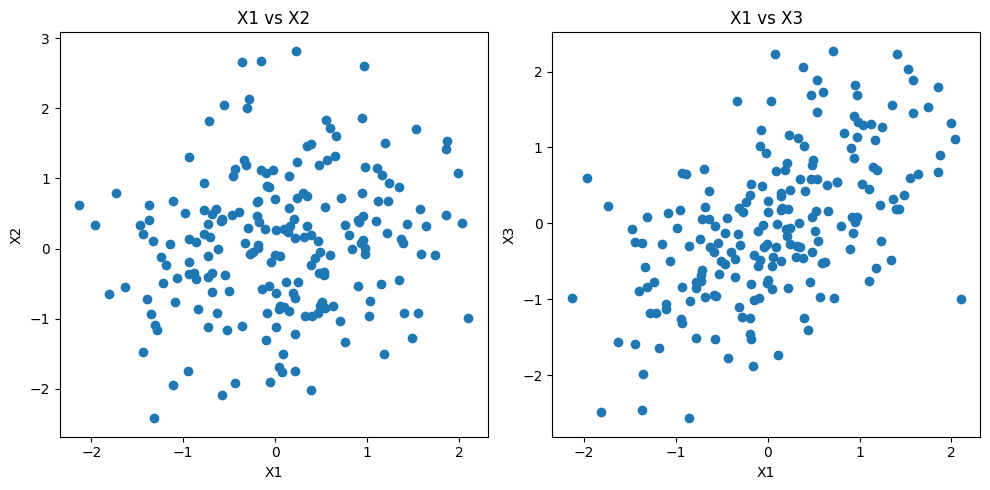

In [ ]:
r1 = 0.1
r2 = 0.6

X2 = r1 * X1 + np.sqrt(1 - pow(r1, 2)) * np.random.normal(0, 1, N)
X3 = r2 * X1 + np.sqrt(1 - pow(r2, 2)) * np.random.normal(0, 1, N)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(X1, X2)
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('X1 vs X2')

axes[1].scatter(X1, X3)
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('X1 vs X3')

plt.tight_layout()
plt.show()

In [20]:
r_hat_1 = np.corrcoef(X1, X2)[0, 1]
r_hat_2 = np.corrcoef(X1, X3)[0, 1]
print(f"Выборочный коэффициент корреляции r^1: {r_hat_1:.3f}")
print(f"Выборочный коэффициент корреляции r^2: {r_hat_2:.3f}")

Выборочный коэффициент корреляции r^1: 0.149
Выборочный коэффициент корреляции r^2: 0.550


In [24]:
# Статистика Стьюдента
t_stat_1 = r_hat_1 * np.sqrt(N - 2) / np.sqrt(1 - r_hat_1**2)
t_stat_2 = r_hat_2 * np.sqrt(N - 2) / np.sqrt(1 - r_hat_2**2)

# Критическое значение (для уровня значимости 0.05)
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, N - 2)

# Проверка гипотезы
p_value_1 = 2 * (1 - stats.t.cdf(abs(t_stat_1), N - 2))
p_value_2 = 2 * (1 - stats.t.cdf(abs(t_stat_2), N - 2))

print(f"Статистика Стьюдента t_1: {t_stat_1:.3f}")
print(f"Статистика Стьюдента t_2: {t_stat_2:.3f}")
print(f"Критическое значение: {t_critical:.3f}")
print(f"p-value_1: {p_value_1:.4f}")
print(f"p-value_2: {p_value_2:.4f}")

print("Для r^1")
if abs(t_stat_1) > t_critical:
    print("Отвергаем нулевую гипотезу: корреляция значима.")
else:
    print("Не отвергаем нулевую гипотезу: корреляция не значима.")
    
print("Для r^2")
if abs(t_stat_2) > t_critical:
    print("Отвергаем нулевую гипотезу: корреляция значима.")
else:
    print("Не отвергаем нулевую гипотезу: корреляция не значима.")

Статистика Стьюдента t_1: 2.126
Статистика Стьюдента t_2: 9.276
Критическое значение: 1.972
p-value_1: 0.0347
p-value_2: 0.0000
Для r^1
Отвергаем нулевую гипотезу: корреляция значима.
Для r^2
Отвергаем нулевую гипотезу: корреляция значима.


In [25]:
# Z-преобразование Фишера
Z = 0.5 * np.log((1 + r_hat_1) / (1 - r_hat_1))

# Стандартная ошибка для Z
SE_Z = 1 / np.sqrt(N - 3)

# Доверительный интервал для Z (уровень значимости 0.05)
Z_critical = stats.norm.ppf(1 - alpha / 2)
Z_lower = Z - Z_critical * SE_Z
Z_upper = Z + Z_critical * SE_Z

# Обратное преобразование в r
r_lower = (np.exp(2 * Z_lower) - 1) / (np.exp(2 * Z_lower) + 1)
r_upper = (np.exp(2 * Z_upper) - 1) / (np.exp(2 * Z_upper) + 1)

print("Для r^1")
print(f"Доверительный интервал для корреляционного коэффициента: ({r_lower:.3f}, {r_upper:.3f})")

Для r^1
Доверительный интервал для корреляционного коэффициента: (0.011, 0.282)


In [26]:
# Z-преобразование Фишера
Z = 0.5 * np.log((1 + r_hat_2) / (1 - r_hat_2))

# Стандартная ошибка для Z
SE_Z = 1 / np.sqrt(N - 3)

# Доверительный интервал для Z (уровень значимости 0.05)
Z_critical = stats.norm.ppf(1 - alpha / 2)
Z_lower = Z - Z_critical * SE_Z
Z_upper = Z + Z_critical * SE_Z

# Обратное преобразование в r
r_lower = (np.exp(2 * Z_lower) - 1) / (np.exp(2 * Z_lower) + 1)
r_upper = (np.exp(2 * Z_upper) - 1) / (np.exp(2 * Z_upper) + 1)

print("Для r^2")
print(f"Доверительный интервал для корреляционного коэффициента: ({r_lower:.3f}, {r_upper:.3f})")

Для r^2
Доверительный интервал для корреляционного коэффициента: (0.446, 0.640)
